# 1. Build a basic chatbot using langgraph (GRAPH API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# add_messages is a utility function called as reducers.
# So when we will ask our chatbot questions, it will respons. And we have a state that will be updated with the response. So we will have a state graph that will be updated with the response.
# Now we dont want to overwrite the state graph with the new response, we want to keep the previous state graph and add the new response to it. So we will use the add_messages function to add the new response to the state graph.
# So add_message is one of the reducers that we can use to update the state graph with the new response. We can also use other reducers like set_messages, clear_messages, etc. But for this example, we will use add_messages.

In [2]:
class State(TypedDict):
    messages: Annotated[list[str], add_messages]
    # Annotated is a mechanism to attach arbitrary metadata to type hints without changing how type checkers or the runtime view the underlying type.
    # In the context of LangGraph, your code defines a state where messages is a list of strings, 
    # but it has a special instructor metadata tag ("add_messages") that tells LangGraph how to merge new messages into that list.

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")
# llm=init_chat_model("groq:llama-3.1-8b-instant")

In [5]:
# definition of a node in the graph.
def chatbot(state:State):
    #here the state["messages"] is the input to the llm model. So we are passing the messages to the llm model and getting the response.
    llm_message = llm.invoke(state["messages"]) 
    #here we are returning the response from the llm model and updating the state with the new response. Aka appending the new response to the messages list in the state.
    return {"messages": [llm_message]}

In [6]:
# We are saying the graph that what is the shape of the state by passing the state
# StateGraph is the Graph canvas where we will define the nodes and edges of the graph.
graph_builder = StateGraph(State)

# Adding Node to the graph
graph_builder.add_node("llmchatbot", chatbot)

# Adding edges to the graph
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# compiling the graphbuilder
graph = graph_builder.compile()

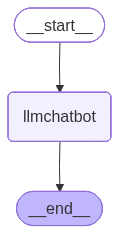

In [7]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
# invoking the graph with initial state
response = graph.invoke({"messages": "Hi"})

In [9]:
# Fetching the last message from the response
last_message = response["messages"][-1].content
last_message

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [10]:
# Streaming a graph with initial state
for event in graph.stream({"messages": "Hi, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

# .invoke()  →  waits for full graph → returns final state (one shot)
# .stream()  →  yields after each node → you get updates as they happen

I'm doing well, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm always happy to chat with you and help with any questions or topics you'd like to discuss. How about you? How's your day going?


# 2. Chatbot With Tool

In [11]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=2)
tavily_tool.invoke("What is LangGraph?")

{'query': 'What is LangGraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': '*   [Overview](https://www.ibm.com/think/topics/ai-agents#7281535). *   [What is agentic AI?](https://www.ibm.com/think/topics/agentic-ai#2095054954). *   [Overview](https://www.ibm.com/think/topics/ai-agent-development#1083937704). *   [Building AI agents](https://www.ibm.com/think/topics/how-to-build-an-ai-agent#1083937709). *   [Overview](https://www.ibm.com/think/topics/ai-agent-types#72820454). *   [Overview](https://www.ibm.com/think/topics/components-of-ai-agents#498277090). *   [Communication](https://www.ibm.com/think/topics/ai-agent-communication#498277088). *   [Learning](https://www.ibm.com/think/topics/ai-agent-learning#498277087). *   [Memory](https://www.ibm.com/think/topics/ai-agent-memory#498277086). *   [Perception](https://www.ibm.com/think/topics/ai-agen

In [12]:
# Custom tool function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [13]:
tools = [tavily_tool, multiply]

In [14]:
# binding llm with tools
# This only makes llm know that what are the tools available to it.
llm_with_tools = llm.bind_tools(tools)

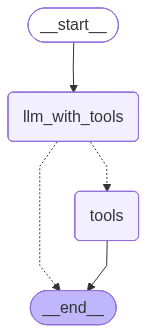

In [22]:
# state graph with tools
# from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


# tool_calling_llm node defination
def tool_calling_llm(state:State):
    # here we are passing the state["messages"] to the llm_with_tools and getting the response. So we are passing the messages to the llm_with_tools and getting the response.
    llm_message = llm_with_tools.invoke(state["messages"])
    # here we are returning the response from the llm_with_tools and updating the state with the new response. Aka appending the new response to the messages list in the state.
    return {"messages": [llm_message]}

# tools node
builder = StateGraph(State)
builder.add_node("llm_with_tools", tool_calling_llm) # creating a node and we are saying that this node is a tool calling llm node and it will invoke the llm_with_tools that we have defined above. So when we will invoke this node, it will invoke the llm_with_tools that we have defined above.
builder.add_node("tools", ToolNode(tools)) # creating a tool node and we are saying that this node is a tool node and it will have the tools that we have defined above. So when we will invoke this node, it will invoke the tools that we have defined above.

builder.add_edge(START, "llm_with_tools")
builder.add_conditional_edges(
    "llm_with_tools",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
# The flow:

# User: "What is 5 * 6?"

# 1. LLM receives the message + knows about [tavily_tool, multiply]
# 2. LLM decides: "I should use multiply for this" -> 
# When you do bind_tools(tools), LangGraph extracts the schema of each tool and sends it to the LLM as part of the API request. That schema includes the function name, description, and parameter types.
# So the LLM isn't guessing — it's reading the tool's description(docstring) and deciding based on that.

# LangGraph converts the tools into a JSON schema and sends it to the LLM API in every request.

# 3. LLM returns an AIMessage with tool_calls field populated:

#    AIMessage(
#      content="",
#      tool_calls=[{
#        "name": "multiply",
#        "args": {"a": 5, "b": 6},
#        "id": "call_abc123"
#      }]
#    )

# 4. tools_condition inspects this AIMessage
# 5. Sees tool_calls is non-empty → routes to "tools" node
# 6. ToolNode executes multiply(5, 6) → returns 30
# 7. Result added to messages as ToolMessage

# LangGraph calls tools_condition(state) after every llm_with_tools node execution, and routes based on what it returns. 
# You're not skipping the condition — tools_condition is the condition, just pre-written for you.

In [25]:
# invoke the graph with initial state
response = graph.invoke({"messages": "What is 5 * 6?"})

In [ ]:
# response
response['messages'][-1].content

'30'

In [32]:
response_news = graph.invoke({"messages": "What is latest ai news?"})

In [34]:
# response_news
response_news['messages'][-1].content

'{"query": "latest ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-waymos-robotaxi-recall", "title": "Fox News AI Newsletter: Waymo\'s robotaxi recall - Fox News", "score": 0.6991933, "published_date": "Fri, 26 Jun 2026 18:02:38 GMT", "content": "Market data provided by Factset. Mutual Fund and ETF data provided by LSEG. # Fox News AI Newsletter: Waymo\'s robotaxi recall. ## Stay up to date on the latest AI technology advancements and learn about the challenges and opportunities AI presents. By Fox News Staff  Fox News. ### **Welcome to Fox News\' Artificial Intelligence newsletter with the latest AI technology advancements.**. According to the National Highway Traffic Safety Administration, the software may allow a Waymo vehicle to enter a closed freeway construction zone and continue driving. **TECH TITAN:** Microsoft CEO Satya Nadella issued a warning that the tech giants competing in the AI race ne

In [35]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 * 6?
================================== Ai Message ==================================
Tool Calls:
  multiply (f612f058z)
 Call ID: f612f058z
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: multiply

30


In [36]:
for m in response_news['messages']:
    m.pretty_print()

================================ Human Message =================================

What is latest ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (p6kh2qryk)
 Call ID: p6kh2qryk
  Args:
    query: latest ai news
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-waymos-robotaxi-recall", "title": "Fox News AI Newsletter: Waymo's robotaxi recall - Fox News", "score": 0.6991933, "published_date": "Fri, 26 Jun 2026 18:02:38 GMT", "content": "Market data provided by Factset. Mutual Fund and ETF data provided by LSEG. # Fox News AI Newsletter: Waymo's robotaxi recall. ## Stay up to date on the latest AI technology advancements and learn about the challenges and opportunities AI presents. By Fox News Staff  Fox